# Bloco 1 - Cargas

In [ ]:
import os

from google.colab import drive
drive.mount('/content/drive')

caminho_pasta = '/content/drive/MyDrive/Projetos/RecomendacaoSpotify'

#os.listdir(caminho_pasta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import pandas as pd
import numpy as np

# Carga
df_musicas = pd.read_parquet(f'{caminho_pasta}/df_musicas_enriquecido.parquet')
df_ranking = pd.read_parquet(f'{caminho_pasta}/df_ranking_final.parquet')


# === ARTISTAS EXCLUÍDOS DAS PLAYLISTS ===
# Decisão totalmente subjetiva e opcional. São execuções reais, que poderiam passar por
# todos os filtros, mas são artistas ou músicas que o usuário pode não querer na playlist
# por motivos pessoais, sem necessidade de justificativa.

caminho_artistas_excluidos = os.path.join(caminho_pasta, 'artistas_excluidos.txt')

if os.path.exists(caminho_artistas_excluidos):
    with open(caminho_artistas_excluidos) as f:
        artistas_excluidos = [l.strip() for l in f.readlines() if l.strip()]
else:
    artistas_excluidos = []
    print('Arquivo de artistas não encontrado — lista vazia.')


print(f'Artistas excluídos: {len(artistas_excluidos)}')
print(artistas_excluidos)

# === MÚSICAS EXCLUÍDAS DAS PLAYLISTS ===
caminho_musicas_excluidas = os.path.join(caminho_pasta, 'musicas_excluidas.txt')

if os.path.exists(caminho_musicas_excluidas):
    with open(caminho_musicas_excluidas) as f:
        musicas_excluidas = [l.strip().replace('-', '—') for l in f.readlines() if l.strip()]
else:
    musicas_excluidas = []
    print('Arquivo de músicas não encontrado — lista vazia.')


print(f'Músicas excluídas: {len(musicas_excluidas)}')
print(musicas_excluidas)






Artistas excluídos: 1
['Anitta']
Músicas excluídas: 3
['A Lua — Pabllo Vittar', 'pot — Novos Baianos', 'áudio de desculpas — Manu Gavassi']


In [ ]:
# === METADADOS DOS CLUSTERS ===
# São informações que são extraídas após a execução do Bloco 3 abaixo - GMM
# Não interferem em nenhuma lógica ou modelo, são apenas explicativas, e serão
# exportadas no final

caminho_meta = os.path.join(caminho_pasta, 'cluster_meta.csv')
df_meta = pd.read_csv(caminho_meta)
df_meta['cluster'] = df_meta['cluster'].astype(int)

print(f'\nClusters carregados: {len(df_meta)}')
print(df_meta.to_string(index=False))


Clusters carregados: 6
 cluster                     cluster_nome                                     cluster_descricao
       0 Exploração de artistas favoritos Longevidade de artista alto - Início intencional alto
       1              Indiferença passiva                          Alta retenção - Pouco replay
       2         Tentativas que não colam     Artistas pouco ouvidos - Poucos plays - Skip alto
       3            Longas e intencionais                         Toca bastante - Retenção alta
       4               Depende do momento  Início intencional baixo - Retenção alta - Skip alto
       5                    Hits Pessoais     Muitos plays - Artistas favoritos - Retenção Alta


In [ ]:
pd.set_option('display.max_columns', None)
display(df_musicas.head(10))

display(df_ranking.head(10))

,ts,ms_played,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,reason_end,shuffle,skipped,offline,data_finalizacao,ano,mes,hora,semana_ano,dia_semana,trimestre,periodo_dia,minutos_tocados,musica_unificada,artista_unificado,rating_lealdade_artista,longevidade_dias_artista,total_plays_artista,dia_ajustado,gap_anterior,sessao_id,posicao_relativa_na_sessao,posicao_sessao_no_dia,duracao_ms,explicit,data_release,duracao_estimada_ms,fonte_duracao,retencao,escuta_completa,skip,inicio_intencional
0,2019-06-21T18:44:56Z,8554,Starman - 2012 Remaster,David Bowie,The Rise and Fall of Ziggy Stardust and the Sp...,spotify:track:0pQskrTITgmCMyr85tb9qq,playbtn,unexpected-exit-while-paused,False,False,False,2019-06-21 18:44:56+00:00,2019,6,18,25,Friday,2,tarde,0.142567,Starman,David Bowie,4.721375,2457,162,2019-06-21,NaN,1,0.000000,0.0,254293,False,1972-06-06,254293,api,0.033638,0.0,False,True
1,2019-06-21T18:46:51Z,73373,Unfinished Allegro,ANGRA,Angels Cry,spotify:track:2rt1yPULHlT6y1cQl1xWZv,clickrow,trackdone,False,False,False,2019-06-21 18:46:51+00:00,2019,6,18,25,Friday,2,tarde,1.222883,Unfinished Allegro,ANGRA,5.832499,2492,479,2019-06-21,1.916667,1,0.007407,0.0,73373,False,1993,73373,api,1.000000,1.0,False,True
2,2019-06-21T18:51:56Z,305093,Carry On,ANGRA,Angels Cry,spotify:track:3f5JMe8WsTVqUMlgWJxhQQ,trackdone,trackdone,False,False,False,2019-06-21 18:51:56+00:00,2019,6,18,25,Friday,2,tarde,5.084883,Carry On,ANGRA,5.832499,2492,479,2019-06-21,5.083333,1,0.014815,0.0,305093,False,1993,305093,api,1.000000,1.0,False,False
3,2019-06-21T18:52:26Z,14065,Time,ANGRA,Angels Cry,spotify:track:0ZOGpndyJeLZ0d7tEiqTq1,trackdone,endplay,False,False,False,2019-06-21 18:52:26+00:00,2019,6,18,25,Friday,2,tarde,0.234417,Time,ANGRA,5.832499,2492,479,2019-06-21,0.500000,1,0.022222,0.0,357773,False,1993,357773,api,0.039313,0.0,False,False
4,2019-06-21T18:53:03Z,36629,Never Understand,ANGRA,Angels Cry,spotify:track:4ioGUGSa2F06jamUHnihdI,clickrow,endplay,False,False,False,2019-06-21 18:53:03+00:00,2019,6,18,25,Friday,2,tarde,0.610483,Never Understand,ANGRA,5.832499,2492,479,2019-06-21,0.616667,1,0.029630,0.0,470000,False,1993,470000,api,0.077934,0.0,False,True
5,2019-06-21T18:53:36Z,33258,Raining Blood,Slayer,Reign In Blood,spotify:track:4fiOTntQKr24p07FvQDHZE,playbtn,fwdbtn,True,False,False,2019-06-21 18:53:36+00:00,2019,6,18,25,Friday,2,tarde,0.554300,Raining Blood,Slayer,2.170875,2314,10,2019-06-21,0.550000,1,0.037037,0.0,255186,False,1986-10-07,255186,api,0.130328,0.0,True,True
6,2019-06-21T18:53:37Z,1557,Cemetery Gates,Pantera,Cowboys from Hell,spotify:track:4vJr55lngvhSM8WIh9CjQc,fwdbtn,fwdbtn,True,False,False,2019-06-21 18:53:37+00:00,2019,6,18,25,Friday,2,tarde,0.025950,Cemetery Gates,Pantera,2.893868,2384,22,2019-06-21,0.016667,1,0.044444,0.0,422933,True,1990-07-20,422933,api,0.003681,0.0,True,False
7,2019-06-21T18:53:43Z,2773,Wasted Years - 2015 Remaster,Iron Maiden,Somewhere in Time,spotify:track:1HM7Vp84E4SMzdrZONg6bH,fwdbtn,fwdbtn,True,False,False,2019-06-21 18:53:43+00:00,2019,6,18,25,Friday,2,tarde,0.046217,Wasted Years,Iron Maiden,4.043761,2454,75,2019-06-21,0.100000,1,0.051852,0.0,309640,False,1986,309640,api,0.008956,0.0,True,False
8,2019-06-21T18:55:17Z,67840,Heroes,Motörhead,Under Cöver,spotify:track:72vjPBpLyuwS5ik1y1E5YE,fwdbtn,fwdbtn,True,False,False,2019-06-21 18:55:17+00:00,2019,6,18,25,Friday,2,tarde,1.130667,Heroes,Motörhead,3.116620,2493,21,2019-06-21,1.566667,1,0.059259,0.0,276999,False,2017-09-01,276999,api,0.244911,0.0,True,False
9,2019-06-21T18:55:20Z,3157,Roots Bloody Roots,Sepultura,Roots,spotify:track:6ursmCnbc9oDRGa2yHKkoZ,fwdbtn,fwdbtn,True,False,False,2019-06-21 18:55:20+00:00,2019,6,18,25,Friday,2,tarde,0.052617,Roots Bloody Roots,Sepultura,4.174373,2492,71,2019-06-21,0.050000,1,0.066667,0.0,212253,False,1996-02-20,212253,api,0.014874,0.0,True,False


,artista_unificado,musica_unificada,total_plays,total_minutos,retencao_media,escuta_completa_rate,skip_rate,inicio_intencional_rate,duracao_estimada_ms,fonte_duracao,data_release,explicit,rating_lealdade_artista,longevidade_dias_artista,total_plays_artista,spotify_track_uri_dominante
0,14 Bis,Linda Juventude,3,4.327433,0.369972,0.333333,0.333333,0.333333,233933.0,api,1982-07-20,False,1.504751,1771,5,spotify:track:5AVGO9BDNucuEb80GKmc5N
1,3 Doors Down,Here Without You,3,4.202833,0.352095,0.333333,0.000000,0.666667,238733.0,api,2002-11-12,False,1.890751,1016,9,spotify:track:3NLrRZoMF0Lx6zTlYqeIo4
2,311,Down,10,6.096267,0.212465,0.200000,0.800000,0.100000,172149.3,api,1995-07-11,False,2.357911,2199,13,spotify:track:0HDaKOlVAfUWXdFR2RhBtN
3,4 Non Blondes,What's Up?,3,9.879067,0.668559,0.666667,0.333333,0.000000,295533.0,api,1992-01-01,False,1.171260,2326,3,spotify:track:0jWgAnTrNZmOGmqgvHhZEm
4,ABBA,Chiquitita,2,5.478133,0.503628,0.500000,0.000000,0.500000,326320.0,api,1979,False,3.560172,1706,50,spotify:track:762B4bOcXF7I2Y8UlKTyTy
5,ABBA,Dancing Queen,9,3.898050,0.112791,0.000000,0.777778,0.222222,230400.0,api,1976,False,3.560172,1706,50,spotify:track:0GjEhVFGZW8afUYGChu3Rr
6,ABBA,Fernando,2,5.566033,0.660108,0.500000,0.000000,0.500000,252960.0,api,1976,False,3.560172,1706,50,spotify:track:4BM8yJ0PzBi2ZewpMTOxtx
7,ABBA,Gimme! Gimme! Gimme! (A Man After Midnight),2,4.255867,0.436331,0.500000,0.000000,0.500000,292613.0,api,1979,False,3.560172,1706,50,spotify:track:3vkQ5DAB1qQMYO4Mr9zJN6
8,ABBA,I Still Have Faith In You,1,5.178667,1.000000,1.000000,0.000000,0.000000,310720.0,api,2021-09-02,False,3.560172,1706,50,spotify:track:3ddxe0WYUpNPtSnHgQOad5
9,ABBA,"Knowing Me, Knowing You",2,4.244967,0.526631,0.500000,0.000000,0.500000,241866.5,api,1976,False,3.560172,1706,50,spotify:track:4VR8erwUal5AIAhX4aBkhv


In [ ]:
df_ranking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   artista_unificado            4212 non-null   object 
 1   musica_unificada             4212 non-null   object 
 2   total_plays                  4212 non-null   int64  
 3   total_minutos                4212 non-null   float64
 4   retencao_media               4212 non-null   float64
 5   escuta_completa_rate         4212 non-null   float64
 6   skip_rate                    4212 non-null   float64
 7   inicio_intencional_rate      4212 non-null   float64
 8   duracao_estimada_ms          4212 non-null   float64
 9   fonte_duracao                4212 non-null   object 
 10  data_release                 4212 non-null   object 
 11  explicit                     4212 non-null   bool   
 12  rating_lealdade_artista      4212 non-null   float64
 13  longevidade_dias_a

# Bloco 2 - PCA

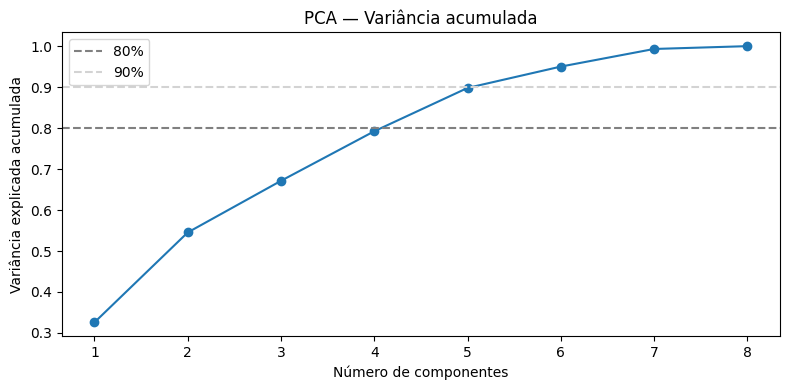

PC1: 32.6%
PC2: 54.5%
PC3: 67.1%
PC4: 79.2%
PC5: 89.8%
PC6: 95.0%
PC7: 99.3%
PC8: 100.0%


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# === FEATURES ===
features_pca = [
    'retencao_media',
    'escuta_completa_rate',
    'skip_rate',
    'inicio_intencional_rate',
    'duracao_estimada_ms',
    'rating_lealdade_artista',
    'longevidade_dias_artista',
    'total_plays'
]

X = df_ranking[features_pca].copy()

# === NORMALIZAÇÃO ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === PCA — todas as componentes para análise de variância ===
pca_full = PCA()
pca_full.fit(X_scaled)

variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# === GRÁFICO: Variância explicada acumulada ===
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o')
plt.axhline(y=0.80, color='gray', linestyle='--', label='80%')
plt.axhline(y=0.90, color='lightgray', linestyle='--', label='90%')
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada acumulada')
plt.title('PCA — Variância acumulada')
plt.legend()
plt.tight_layout()
plt.show()

# === RESUMO ===
for i, v in enumerate(variancia_acumulada):
    print(f'PC{i+1}: {v:.1%}')

In [ ]:
# === PCA FINAL — 5 COMPONENTES ===
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# === DATAFRAME DE COMPONENTES ===
colunas_pca = [f'PC{i+1}' for i in range(5)]
df_pca = pd.DataFrame(X_pca, columns=colunas_pca, index=df_ranking.index)

# Anexa identificadores para rastreabilidade
df_pca['musica_unificada'] = df_ranking['musica_unificada'].values
df_pca['artista_unificado'] = df_ranking['artista_unificado'].values
df_pca['spotify_track_uri_dominante'] = df_ranking['spotify_track_uri_dominante'].values

# === LOADINGS — entender o que cada PC representa ===
df_loadings = pd.DataFrame(
    pca.components_,
    columns=features_pca,
    index=colunas_pca
)

print("=== LOADINGS ===")
print(df_loadings.round(3))

=== LOADINGS ===
     retencao_media  escuta_completa_rate  skip_rate  inicio_intencional_rate  \
PC1           0.594                 0.573     -0.491                   -0.092   
PC2           0.101                 0.134      0.100                   -0.353   
PC3           0.001                -0.015     -0.345                    0.756   
PC4           0.040                 0.027     -0.191                    0.182   
PC5           0.104                 0.123      0.004                   -0.348   

     duracao_estimada_ms  rating_lealdade_artista  longevidade_dias_artista  \
PC1               -0.157                   -0.082                    -0.076   
PC2               -0.234                    0.630                     0.497   
PC3               -0.072                    0.214                    -0.072   
PC4                0.736                    0.134                     0.539   
PC5                0.601                   -0.010                    -0.424   

     total_plays  
PC

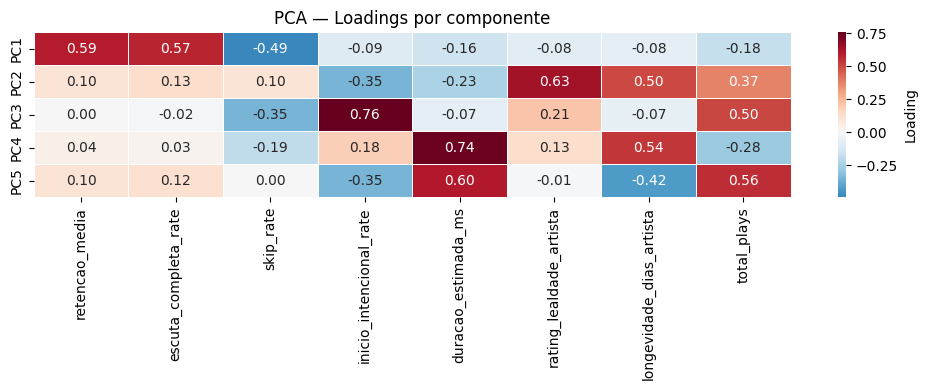

In [ ]:
# Heatmap para facilitar a visualização

import seaborn as sns

plt.figure(figsize=(10, 4))
sns.heatmap(
    df_loadings,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Loading'}
)
plt.title('PCA — Loadings por componente')
plt.tight_layout()
plt.show()

# Bloco 3 - GMM

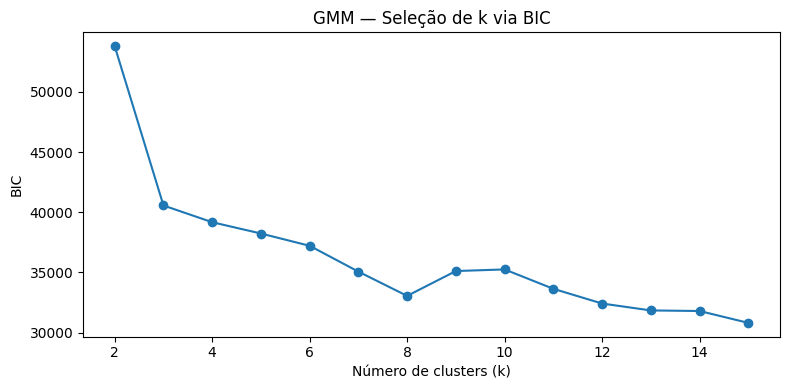

k= 2: BIC=53,808.9
k= 3: BIC=40,563.8
k= 4: BIC=39,172.3
k= 5: BIC=38,232.7
k= 6: BIC=37,210.8
k= 7: BIC=35,062.9
k= 8: BIC=33,045.2
k= 9: BIC=35,112.9
k=10: BIC=35,246.6
k=11: BIC=33,634.0
k=12: BIC=32,410.9
k=13: BIC=31,837.6
k=14: BIC=31,789.4
k=15: BIC=30,802.0


In [ ]:
# ============================================================
# NB4 — BLOCO 3: GMM — seleção de k via BIC
# ============================================================

from sklearn.mixture import GaussianMixture

bic_scores = []
k_range = range(2, 16)

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))

# === GRÁFICO ===
plt.figure(figsize=(8, 4))
plt.plot(k_range, bic_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('BIC')
plt.title('GMM — Seleção de k via BIC')
plt.tight_layout()
plt.show()

# === RESUMO ===
for k, bic in zip(k_range, bic_scores):
    print(f'k={k:2d}: BIC={bic:,.1f}')

In [ ]:
# === GMM FINAL — k=6 ===
gmm = GaussianMixture(n_components=6, covariance_type='full', random_state=42)
gmm.fit(X_pca)

df_ranking['cluster'] = gmm.predict(X_pca)
df_ranking['cluster_prob_max'] = gmm.predict_proba(X_pca).max(axis=1)

# === DISTRIBUIÇÃO DOS CLUSTERS ===
print("=== DISTRIBUIÇÃO ===")
print(df_ranking['cluster'].value_counts().sort_index())

print("\n=== PERFIL MÉDIO POR CLUSTER ===")
print(df_ranking.groupby('cluster')[features_pca].mean().round(3))

=== DISTRIBUIÇÃO ===
cluster
0     909
1    1051
2     563
3     201
4    1216
5     272
Name: count, dtype: int64

=== PERFIL MÉDIO POR CLUSTER ===
         retencao_media  escuta_completa_rate  skip_rate  \
cluster                                                    
0                 0.627                 0.552      0.112   
1                 1.000                 1.000      0.000   
2                 0.620                 0.549      0.117   
3                 0.557                 0.485      0.154   
4                 0.594                 0.556      0.289   
5                 0.729                 0.696      0.143   

         inicio_intencional_rate  duracao_estimada_ms  \
cluster                                                 
0                          0.522           216962.899   
1                          0.000           216409.533   
2                          0.570           224542.855   
3                          0.513           409428.860   
4                          0

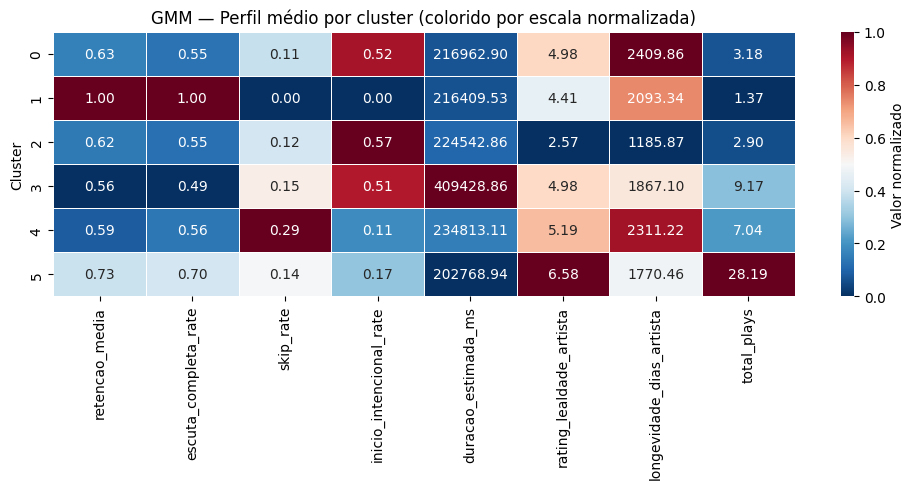

In [ ]:
perfil = df_ranking.groupby('cluster')[features_pca].mean()
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

plt.figure(figsize=(10, 5))
sns.heatmap(
    perfil_norm,
    annot=perfil.round(2),
    fmt='.2f',
    cmap='RdBu_r',
    center=0.5,
    linewidths=0.5,
    cbar_kws={'label': 'Valor normalizado'}
)
plt.title('GMM — Perfil médio por cluster (colorido por escala normalizada)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [ ]:
pd.set_option('display.max_columns', None) # Set option to display all columns
print('=== Amostra de 10 músicas aleatórias por cluster ===')
for cluster_id in sorted(df_ranking['cluster'].unique()):
    print(f'\n--- Cluster {cluster_id} ---')
    sample = df_ranking[df_ranking['cluster'] == cluster_id].sample(n=10, random_state=42)
    display(sample)


=== Amostra de 10 músicas aleatórias por cluster ===

--- Cluster 0 ---


,artista_unificado,musica_unificada,total_plays,total_minutos,retencao_media,escuta_completa_rate,skip_rate,inicio_intencional_rate,duracao_estimada_ms,fonte_duracao,data_release,explicit,rating_lealdade_artista,longevidade_dias_artista,total_plays_artista,spotify_track_uri_dominante,cluster,cluster_prob_max
4058,Titãs,Medo,3,2.298717,0.365534,0.333333,0.000000,0.333333,125773.00,api,1989-12-20,False,5.471923,2487,337,spotify:track:1LO1K3N8KW77u39ewlK0L7,0,0.986415
2627,Ney Matogrosso,Mi Unicornio Azul,2,2.562133,0.299989,0.000000,0.000000,1.000000,255705.00,api,2021-08-01,False,3.641838,2343,52,spotify:track:5p5bes9YLuG6ARZoVfaRTJ,0,0.765052
2121,Legião Urbana,Vinte E Nove,4,7.671400,0.519349,0.500000,0.500000,0.250000,197959.75,api,1993-01-01,False,6.304735,2492,825,spotify:track:4D75ixy2I4ft75Ay25fKyP,0,0.761381
3740,The Beatles,Now And Then,1,4.138883,1.000000,1.000000,0.000000,1.000000,248333.00,api,2023-11-02,False,6.303275,2501,422,spotify:track:4vziJcnB2Qyi9o4nIRUeN7,0,0.990898
3846,The Offspring,Walla Walla,1,2.333600,0.790814,1.000000,0.000000,1.000000,177053.00,api,1998-11-16,False,4.570741,2430,144,spotify:track:4Kk6O5Q7UAgxP0QwyES72F,0,0.928105
3996,The Who,The Real Me,2,3.586067,0.536030,0.500000,0.000000,0.500000,200673.00,api,1973-10-19,False,3.218397,2337,33,spotify:track:0bNdtECaLZcHA4B9QPjeUk,0,0.845482
2980,Pink Floyd,The Great Gig in the Sky,4,4.601000,0.221548,0.000000,0.500000,0.250000,305323.00,api,1973-03-01,False,6.564940,2391,572,spotify:track:2TjdnqlpwOjhijHCwHCP2d,0,0.773728
1680,Green Day,Nice Guys Finish Last,4,3.180467,0.282512,0.250000,0.250000,0.500000,168866.00,api,1997-10-14,True,5.276679,2446,315,spotify:track:0EonrvTzzNScmk7QT4L3dw,0,0.987710
4196,blink-182,Carousel,3,6.498667,0.666667,0.666667,0.333333,0.333333,194960.00,api,1995,False,4.959010,2465,208,spotify:track:3gVXAW2pduBl7tzjAGUVRb,0,0.887664
3739,The Beatles,Norwegian Wood (This Bird Has Flown),5,5.192017,0.499661,0.400000,0.600000,0.200000,124693.00,api,1965-12-03,False,6.303275,2501,422,spotify:track:1H7gMYGykdtwZOV6s1N0by,0,0.724219



--- Cluster 1 ---


,artista_unificado,musica_unificada,total_plays,total_minutos,retencao_media,escuta_completa_rate,skip_rate,inicio_intencional_rate,duracao_estimada_ms,fonte_duracao,data_release,explicit,rating_lealdade_artista,longevidade_dias_artista,total_plays_artista,spotify_track_uri_dominante,cluster,cluster_prob_max
1110,Detonautas Roque Clube,O dia que não terminou,1,4.227550,1.000000,1.0,0.0,0.0,253653.0,api,2010-03-09,False,2.232776,640,14,spotify:track:1wywpyTBWYRFCRhSGyRKeW,1,0.999996
2648,Nick Mason's Saucerful of Secrets,Remember a Day,2,7.076017,0.997685,1.0,0.0,0.0,212773.0,api,2020-09-18,False,3.061702,157,36,spotify:track:7HbkNSkmetQBvMtLTVIjmE,1,0.999742
1729,IDLES,Dancer,2,6.316433,1.000000,1.0,0.0,0.0,189493.0,api,2024-02-16,False,2.660821,1340,18,spotify:track:15uzP4I5pMX4dfQ9Lx72h1,1,0.999997
1447,Falamansa,Confidência,1,3.651100,1.000000,1.0,0.0,0.0,219066.0,api,2000,False,3.000538,2222,27,spotify:track:3XA3NYOoFxiLQe0OLtQlNw,1,0.999996
152,Angela Ro Ro,Na Cama,2,7.925333,1.000000,1.0,0.0,0.0,237760.0,api,1981-01-01,False,1.856365,1247,8,spotify:track:7HhwhQSrQo0dDGxBzTTKwQ,1,0.999998
1603,Gentle Giant,Isn't It Quiet And Cold,1,3.864433,1.000000,1.0,0.0,0.0,231866.0,api,1970-01-01,False,2.733911,775,17,spotify:track:48Xi5SxPbespCwJT2cr9Kw,1,0.999995
595,Belchior,Não Leve Flores,2,8.387983,1.000000,1.0,0.0,0.0,251639.5,api,1976-01-01,False,3.091431,2162,29,spotify:track:4uNlGchuCK789YjDD0fBhV,1,0.999993
1531,Gabriel O Pensador,Filho da Pátria Iludido,1,5.150450,1.000000,1.0,0.0,0.0,309026.0,api,1995-04-28,False,1.858612,2112,7,spotify:track:5HTiOxOZ7fwGYLPyIYrb20,1,0.999998
362,Bad Religion,American Dream,3,5.075333,1.000000,1.0,0.0,0.0,101506.0,api,1982,False,8.107261,2495,3368,spotify:track:5Psp6xsuDRK4iexOroxVBI,1,0.999950
2754,Os Mutantes,Quem Tem Medo De Brincar De Amor,1,3.751333,1.000000,1.0,0.0,0.0,225080.0,api,1970-01-01,False,3.942594,2414,70,spotify:track:0F1AMVwnyVwWpSa1Lryd5r,1,0.999994



--- Cluster 2 ---


...

,artista_unificado,musica_unificada,total_plays,total_minutos,retencao_media,escuta_completa_rate,skip_rate,inicio_intencional_rate,duracao_estimada_ms,fonte_duracao,data_release,explicit,rating_lealdade_artista,longevidade_dias_artista,total_plays_artista,spotify_track_uri_dominante,cluster,cluster_prob_max
2109,Legião Urbana,Soldados/Blues Da Piedade/Faz Parte Do Meu Sho...,6,40.365550,0.848611,0.666667,0.000000,0.333333,475666.000000,api,1992-01-01,False,6.304735,2492,825,spotify:track:3507ZrI1ysHVcyPe3VgMWk,3,0.894251
298,Arnaldo Antunes,Sem Você (Música Incidental: Preta Pretinha),13,35.259933,0.821027,0.846154,0.000000,0.692308,198213.000000,api,2012-04-15,False,6.408025,2479,1020,spotify:track:5dtEWuCYpd8oUlLVaRKTpB,3,0.828559
702,Black Pantera,R.I.S.E.,5,3.434467,0.342439,0.200000,0.600000,0.000000,120353.000000,api,2023-11-17,False,7.194079,722,1283,spotify:track:7ctORSsxKdiwCUPaMuGkre,3,0.989189
2990,Pink Floyd,Us and Them,5,17.828950,0.452678,0.400000,0.000000,0.800000,472626.000000,api,1973-03-01,False,6.564940,2391,572,spotify:track:1TKTiKp3zbNgrBH2IwSwIx,3,0.995033
2699,Oasis,All Around the World,4,10.500583,0.281321,0.250000,0.500000,0.500000,559800.000000,api,1997-07-08,False,5.120563,2470,247,spotify:track:4zPwB1GH1luYP8dF6oCk1b,3,0.999201
2345,Manu Gavassi,áudio de desculpas,21,29.879983,0.483817,0.428571,0.190476,0.666667,176454.000000,api,2019-09-13,False,4.111894,2070,94,spotify:track:1JP3iGUerYKKYQwXGQGYks,3,0.978330
1809,Ira!,Efeito Dominó,19,98.966800,0.732636,0.789474,0.000000,0.631579,425148.315789,api,2020-06-05,False,4.704006,2427,163,spotify:track:5Je8S5k4csGFI6RhD3Udhl,3,0.993715
3191,Racionais MC's,Homem na Estrada,2,17.716467,0.991864,1.000000,0.000000,0.500000,521826.000000,api,1993-07-10,False,2.972404,1434,26,spotify:track:36fttUvKnvYuzB5ASzxhkD,3,0.998982
3238,Rage Against The Machine,People of the Sun,13,13.403250,0.412225,0.384615,0.153846,0.538462,150066.000000,api,1996-04-16,False,5.459284,2465,370,spotify:track:3QjQp2bfAvLTCSi8Zhzqis,3,0.926786
1159,"Emerson, Lake & Palmer","The Endless Enigma, Pt. 1",4,13.997133,0.521901,0.500000,0.000000,1.000000,402293.000000,api,1972-07-06,False,3.829768,1624,57,spotify:track:6OVttNYOTZGwRwEVvcpB65,3,0.716201



--- Cluster 4 ---


,artista_unificado,musica_unificada,total_plays,total_minutos,retencao_media,escuta_completa_rate,skip_rate,inicio_intencional_rate,duracao_estimada_ms,fonte_duracao,data_release,explicit,rating_lealdade_artista,longevidade_dias_artista,total_plays_artista,spotify_track_uri_dominante,cluster,cluster_prob_max
1775,Inocentes,Intolerância,4,14.710033,0.966637,1.000000,0.000000,0.000000,228266.000000,api,1996-03-19,False,5.115164,1952,223,spotify:track:0JRBvbbjmJ6onalT36ZW9K,4,0.942658
1035,David Bowie,Heroes,5,24.864683,0.803354,0.800000,0.000000,0.200000,371413.000000,api,1977,False,4.721375,2457,162,spotify:track:7Jh1bpe76CNTCgdgAdBw4Z,4,0.706911
112,Alceu Valença,Eu Vou Fazer Você Voar,1,2.356783,0.654501,1.000000,0.000000,0.000000,216053.000000,api,2019-11-11,False,4.133197,2156,83,spotify:track:2RzuiQcbRYMK4HlnhzSmDF,4,0.656626
3385,Raul Seixas,O Trem Das 7,9,13.678750,0.574911,0.555556,0.444444,0.000000,158663.444444,api,1974-03-29,False,5.474579,2468,374,spotify:track:6zAxMr8eEf2TKUevXwKykM,4,0.919947
1951,Joy Division,Love Will Tear Us Apart,13,17.569717,0.389833,0.307692,0.307692,0.307692,207964.692308,api,1980-06-01,False,2.518037,2129,15,spotify:track:34iOH7LY3vme5rQxsVILZ4,4,0.825658
1218,Engenheiros e Humberto Gessinger,Bora,6,6.619800,0.272159,0.166667,0.666667,0.000000,246737.500000,api,2013-09-03,False,7.336591,2493,2668,spotify:track:2a2DNUfRH9pa50PEgWOEuc,4,0.800743
2122,Legião Urbana,Índios,22,15.634617,0.152077,0.136364,0.818182,0.090909,284959.227273,api,1986-01-01,False,6.304735,2492,825,spotify:track:3N5VoWNA2TWay0UML62STK,4,0.898195
4199,blink-182,Dumpweed,3,3.184100,0.442565,0.333333,0.666667,0.000000,143893.000000,api,1999-06-01,True,4.959010,2465,208,spotify:track:5SlKhaPcdIfSjpoM2QtM4C,4,0.702460
806,Bush,Machinehead,14,11.583467,0.193668,0.142857,0.571429,0.285714,256333.000000,api,1994-12-06,False,4.683010,2457,155,spotify:track:1wrhhPzd2ncJPNgUcGgBGg,4,0.982248
590,Belchior,A Palo Seco,3,5.940267,0.673802,0.666667,0.333333,0.000000,176346.666667,api,1976-01-01,False,3.091431,2162,29,spotify:track:02Alfcz9tiZnoEj5fki2Al,4,0.719402



--- Cluster 5 ---


,artista_unificado,musica_unificada,total_plays,total_minutos,retencao_media,escuta_completa_rate,skip_rate,inicio_intencional_rate,duracao_estimada_ms,fonte_duracao,data_release,explicit,rating_lealdade_artista,longevidade_dias_artista,total_plays_artista,spotify_track_uri_dominante,cluster,cluster_prob_max
382,Bad Religion,Change Of Ideas,22,15.699500,0.769052,0.727273,0.181818,0.227273,55306.000000,api,1989,False,8.107261,2495,3368,spotify:track:5xesgknt9epKNcaMq6irot,5,0.451992
700,Black Pantera,Prefácio,21,49.830167,0.757229,0.714286,0.047619,0.333333,188044.666667,api,2017-11-09,False,7.194079,722,1283,spotify:track:64hNdcvvPXoa1FieLcmvgo,5,0.992386
653,Black Pantera,BLACK BOOK CLUB,40,80.445867,0.618451,0.575000,0.275000,0.025000,195776.250000,api,2024-05-24,False,7.194079,722,1283,spotify:track:6gVptkTQOda4rY1LB61sN0,5,0.999995
714,Black Pantera,Taca o Foda-se,17,36.473917,0.634120,0.588235,0.176471,0.117647,203008.000000,api,2018-03-30,False,7.194079,722,1283,spotify:track:4CviuI6rZIf3m9bsO9XWWO,5,0.987475
2148,Liniker,Calmô,23,70.336833,0.719894,0.739130,0.043478,0.434783,254558.000000,api,2018-10-30,False,6.494087,1550,683,spotify:track:2flDia8RwKyi1S1I1kTY7w,5,0.960872
1216,Engenheiros e Humberto Gessinger,Bem a Fim,32,75.894617,0.812976,0.781250,0.125000,0.343750,174733.000000,api,2019-10-11,False,7.336591,2493,2668,spotify:track:7zRdkWFkoPh38XG54QgM7d,5,0.998072
2173,Liniker,POTE DE OURO,14,36.139617,0.648436,0.642857,0.142857,0.142857,238858.000000,api,2024-08-19,False,6.494087,1550,683,spotify:track:3f1lEgEorble8TWplM949r,5,0.942457
452,Bad Religion,Lose Your Head,51,113.043200,0.784722,0.784314,0.137255,0.078431,169704.254902,api,2019-05-03,False,8.107261,2495,3368,spotify:track:1PAPt6Ovo1ljOSG1enpymb,5,1.000000
1568,Garotos Podres,Garoto Podre,15,34.656233,0.746654,0.600000,0.200000,0.066667,185738.000000,api,1988,False,6.328396,1914,442,spotify:track:3FSHyGGNdodF9gFxe1w36b,5,0.844523
3112,Plebe Rude,Pressão Social,25,57.711850,0.825310,0.800000,0.120000,0.040000,167826.000000,api,2005-01-01,False,6.122022,2494,574,spotify:track:7vTL6WDfXhULW9VjgVjF86,5,0.987836


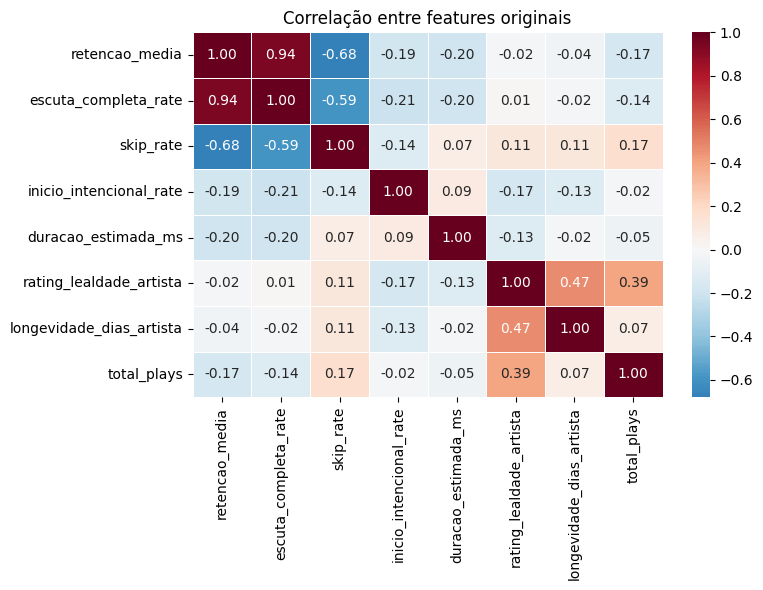

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_ranking[features_pca].corr().round(2),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)
plt.title('Correlação entre features originais')
plt.tight_layout()
plt.show()

**O PCA foi justificado pela multicolinearidade detectada nas features de comportamento de escuta (r=0.91 entre retenção e escuta completa). As 5 componentes retidas capturam 89.4% da variância com dimensões ortogonais, garantindo que o GMM opere sem distorção por redundância.**



# Bloco 4 Item2Vec

In [ ]:
!pip install gensim

In [ ]:
# ============================================================
# NB4 — BLOCO 4: ITEM2VEC
# ============================================================

from gensim.models import Word2Vec

# Adiciona token composto
df_musicas["token_i2v"] = df_musicas["musica_unificada"] + " — " + df_musicas["artista_unificado"]


# === PREPARA AS SESSÕES ===
sessoes = (
    df_musicas
    .sort_values(['dia_ajustado', 'sessao_id', 'data_finalizacao'])
    .groupby(['dia_ajustado', 'sessao_id'])['token_i2v']
    .apply(list)
    .reset_index(drop=True)
)

# Filtra sessões com pelo menos 2 músicas
sessoes = sessoes[sessoes.apply(len) >= 2].tolist()

print(f'Total de sessões: {len(sessoes)}')
print(f'Exemplo de sessão: {sessoes[0]}')

# === TREINA O MODELO ===
model_i2v = Word2Vec(
    sentences=sessoes,
    vector_size=64,
    window=5,
    min_count=2,
    sg=1,
    epochs=10,
    seed=42
)

print(f'\nVocabulário: {len(model_i2v.wv)} músicas')

# === CRIA DATAFRAME DE EMBEDDINGS ===
vocabulario = list(model_i2v.wv.index_to_key)
embeddings = model_i2v.wv[vocabulario]

colunas_emb = [f'emb_{i}' for i in range(64)]
df_embeddings = pd.DataFrame(embeddings, index=vocabulario, columns=colunas_emb)
df_embeddings.index.name = 'token_i2v'
df_embeddings = df_embeddings.reset_index()

print(f'df_embeddings: {df_embeddings.shape}')

Total de sessões: 1580
Exemplo de sessão: ['Starman — David Bowie', 'Unfinished Allegro — ANGRA', 'Carry On — ANGRA', 'Time — ANGRA', 'Never Understand — ANGRA', 'Raining Blood — Slayer', 'Cemetery Gates — Pantera', 'Wasted Years — Iron Maiden', 'Heroes — Motörhead', 'Roots Bloody Roots — Sepultura', 'No More Mr. Nice Guy — Alice Cooper', 'Painkiller — Judas Priest', 'Painkiller — Judas Priest', 'Fear of the Dark — Iron Maiden', 'Heaven and Hell — Black Sabbath', 'Overkill — Motörhead', 'Whiskey In The Jar — Thin Lizzy', 'Learn to Fly — Foo Fighters', 'Mapas do Acaso — Engenheiros e Humberto Gessinger', 'Realidade Virtual — Engenheiros e Humberto Gessinger', 'Sutilmente — Skank', 'Refrão De Bolero — Engenheiros e Humberto Gessinger', 'A Montanha — Engenheiros e Humberto Gessinger', 'Ando Só — Engenheiros e Humberto Gessinger', 'Eu Que Não Amo Você — Engenheiros e Humberto Gessinger', 'As Minas Do Rei Salomão — Raul Seixas', 'Mosca Na Sopa — Raul Seixas', 'Metamorfose Ambulante — Raul S

In [ ]:
# === UNE EMBEDDINGS COM df_ranking ===

df_ranking["token_i2v"] = df_ranking["musica_unificada"] + " — " + df_ranking["artista_unificado"]


df_ranking_emb = df_ranking.merge(
    df_embeddings,
    on='token_i2v',
    how='left'
)

# Verifica cobertura
total = len(df_ranking_emb)
com_emb = df_ranking_emb['emb_0'].notna().sum()
print(f'Com embedding: {com_emb}/{total} ({com_emb/total:.1%})')

Com embedding: 3010/4212 (71.5%)


In [ ]:
# === MÚSICAS SEM EMBEDDING ===
sem_emb = df_ranking_emb[df_ranking_emb['emb_0'].isna()]

print(f'Músicas sem embedding: {len(sem_emb)}')
print(f'\nDistribuição por cluster:')
print(sem_emb['cluster'].value_counts().sort_index())

print(f'\nTotal de plays (sem embedding):')
print(sem_emb['total_plays'].describe().round(2))

Músicas sem embedding: 1202

Distribuição por cluster:
cluster
0    162
1    788
2    129
3     24
4     98
5      1
Name: count, dtype: int64

Total de plays (sem embedding):
count    1202.00
mean        1.05
std         0.22
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         3.00
Name: total_plays, dtype: float64


# Bloco 5 - Geração de Playlists



**Visão Geral**

As três playlists foram geradas a partir de dados comportamentais reais de escuta,
sem depender de metadados externos como gênero, BPM ou energia. A curadoria é
inteiramente baseada em padrões do próprio histórico: quais músicas foram ouvidas,
quando, como e em que sequência.

O pipeline de geração segue quatro etapas para cada playlist:

1. **Seleção por comportamento e cluster** — filtros de posição na sessão e clusters
   GMM definem o pool de candidatas
2. **Representação vetorial** — embeddings Item2Vec garantem que as músicas
   selecionadas compartilhem contexto de co-ocorrência no histórico
3. **Ordenação por Cadeia de Markov** — as músicas são sequenciadas pela
   probabilidade de transição observada nas sessões reais, buscando a sequência
   mais natural possível
4. **Diversidade por artista** — após a ordenação, excedentes por artista são
   removidos mantendo os melhores posicionados na sequência

A ordenação pela Cadeia de Markov produz um **score de transição acumulado** para
cada playlist — quanto maior o score, mais a sequência se aproxima do fluxo real
de escuta do usuário.

---

**Playlist 1 — Início do Dia (50 músicas)**

Captura o repertório associado aos momentos de abertura do dia. A seleção prioriza
músicas que aparecem frequentemente nas primeiras sessões do dia, com boa retenção
e relevância comprovada no histórico.

O filtro de posição relativa dentro da sessão foi removido após análise — o contexto
de início de dia já é suficientemente capturado pela posição da sessão no dia, e
restringir a posição dentro da sessão reduzia demais o pool, resultando em músicas
com baixo volume de plays e menos transições conhecidas pela Cadeia de Markov.

**Filtros comportamentais:**
- `posicao_sessao_no_dia` <= 0.4 — primeiras 40% das sessões do dia
- `total_plays` >= 3 — garante relevância mínima no histórico
- `freq_contexto` >= 1 — apenas músicas com ao menos uma aparição
  no contexto de início de dia

**Clusters incluídos:**

0: Exploração de artistas favoritos,Longevidade de artista alto - Início intencional alto

3: Longas e intencionais,Toca bastante - Retenção alta

4: Depende do momento,Início intencional baixo - Retenção alta - Skip alto


**Limite por artista:** 3 músicas

---

**Playlist 2 — Fim do Dia (50 músicas)**

Captura o repertório associado ao encerramento do dia. O filtro de posição relativa
na sessão não é aplicado aqui — fim de dia é sobre o contexto geral da sessão,
não sobre onde a música aparece dentro dela.

**Filtros comportamentais:**
- `posicao_sessao_no_dia` >= 0.8 — últimas sessões do dia

**Clusters incluídos:**

3: Longas e intencionais,Toca bastante - Retenção alta

4: Depende do momento,Início intencional baixo - Retenção alta - Skip alto

5: Hits Pessoais,Muitos plays - Artistas favoritos - Retenção Alta

**Limite por artista:** 3 músicas

---

**Playlist 3 — Viagem Longa (100 músicas)**

Playlist sem contexto de horário, projetada para sessões contínuas de várias horas.
Cobre a maior parte do repertório relevante, priorizando qualidade de escuta
e variedade. O skip rate não é filtrado explicitamente — já está capturado pelos
clusters GMM e pela retenção média.

**Filtros comportamentais:**
- `total_plays` >= 3
- `retencao_media` >= 0.6

**Clusters incluídos:**


0: Exploração de artistas favoritos,Longevidade de artista alto - Início intencional alto

1: Indiferença passiva,Alta retenção - Pouco replay

3: Longas e intencionais,Toca bastante - Retenção alta

4: Depende do momento,Início intencional baixo - Retenção alta - Skip alto

5: Hits Pessoais,Muitos plays - Artistas favoritos - Retenção Alta

**Limite por artista:** 6 músicas

---

**Nota sobre músicas sem embedding**

Das 4212 músicas no `df_ranking`, 1202 (28,5%) não possuem representação no espaço
Item2Vec. A ausência de embedding reflete baixo histórico de co-ocorrência —
essas músicas têm média de 1.05 plays, confirmando baixa relevância comportamental.
Essas músicas são descartadas na etapa de seleção.

In [ ]:
# ============================================================
# CADEIA DE MARKOV
# ============================================================

from collections import defaultdict

# === TREINA A CADEIA ===
# Cada sessão é uma sequência de musica_unificada
# Aprende P(musica_j | musica_i) a partir do histórico real

transicoes = defaultdict(lambda: defaultdict(int))

sessoes_markov = (
    df_musicas
    .sort_values(['dia_ajustado', 'sessao_id', 'data_finalizacao'])
    .groupby(['dia_ajustado', 'sessao_id'])['token_i2v']
    .apply(list)
    .reset_index(drop=True)
)

for sessao in sessoes_markov:
    for i in range(len(sessao) - 1):
        origem = sessao[i]
        destino = sessao[i + 1]
        transicoes[origem][destino] += 1

# Normaliza para probabilidades
prob_transicao = {}
for origem, destinos in transicoes.items():
    total = sum(destinos.values())
    prob_transicao[origem] = {d: c / total for d, c in destinos.items()}

# === FREQUÊNCIA DE ABERTURA ===
# Músicas que aparecem com mais frequência no início das sessões
abertura = defaultdict(int)
for sessao in sessoes_markov:
    if len(sessao) >= 1:
        abertura[sessao[0]] += 1

print(f'Músicas com transições conhecidas: {len(prob_transicao)}')
print(f'Músicas com registro de abertura: {len(abertura)}')

Músicas com transições conhecidas: 4071
Músicas com registro de abertura: 1288


In [ ]:
# === FUNÇÃO DE ORDENAÇÃO POR CADEIA DE MARKOV ===

def ordenar_por_markov(pool: list, prob_transicao: dict, abertura: dict) -> tuple:
    """
    Ordena uma lista de músicas usando a Cadeia de Markov.

    - Começa pela música com maior probabilidade de transição
      para as demais do pool (critério local ao pool)
    - Fallback por frequência de abertura global quando empate ou
      nenhuma transição conhecida dentro do pool
    - A cada passo, escolhe a próxima música do pool com maior
      probabilidade de transição a partir da música atual
    - Músicas sem transição conhecida são adicionadas ao final

    Retorna a sequência ordenada e o score de transição médio.
    """
    pool_set = set(pool)
    restantes = set(pool)
    sequencia = []
    score = 0.0

    # Música inicial — maior soma de probabilidades de saída
    # para as outras músicas do pool (ignora transições externas)
    def score_inicial(m):
        transicoes = prob_transicao.get(m, {})
        return sum(p for destino, p in transicoes.items() if destino in pool_set and destino != m)

    scores_iniciais = {m: score_inicial(m) for m in restantes}
    max_score = max(scores_iniciais.values())

    if max_score > 0:
        # Há transições conhecidas — escolhe a de maior score interno
        atual = max(scores_iniciais, key=scores_iniciais.get)
    else:
        # Nenhuma transição conhecida dentro do pool — fallback por abertura global
        atual = max(restantes, key=lambda m: abertura.get(m, 0))

    sequencia.append(atual)
    restantes.remove(atual)

    # Encadeia pelo maior prob de transição
    while restantes:
        transicoes_atual = prob_transicao.get(atual, {})
        candidatas = {m: p for m, p in transicoes_atual.items() if m in restantes}

        if candidatas:
            proxima = max(candidatas, key=candidatas.get)
            score += candidatas[proxima]
        else:
            # Sem transição conhecida — fallback por abertura global
            proxima = max(restantes, key=lambda m: abertura.get(m, 0))

        sequencia.append(proxima)
        restantes.remove(proxima)
        atual = proxima

    score_medio = score / len(sequencia)
    return sequencia, round(score_medio, 4)

print('Função de ordenação pronta.')

Função de ordenação pronta.


In [ ]:
# === FUNÇÃO DE SELEÇÃO E MONTAGEM ===
import warnings
def montar_playlist(
    nome: str,
    df_rank: pd.DataFrame,
    df_mus: pd.DataFrame,
    clusters: list,
    tamanho: int,
    limite_artista: int,
    prob_transicao: dict,
    abertura: dict,
    artistas_excluidos: list = None,
    musicas_excluidas: list = None,
    filtro_posicao: dict = None,
    filtro_extra: dict = None,
    freq_minima: int = 0
):
    """
    filtro_posicao: dict com chaves 'coluna', 'operador', 'valor'
                   ex: {'coluna': 'posicao_sessao_no_dia', 'operador': '<=', 'valor': 0.2}
                   Aceita lista de dicts para múltiplos filtros.
    filtro_extra:  dict com chaves 'coluna', 'operador', 'valor'
                   para filtros adicionais no df_rank
    """
    # === 1. FREQUÊNCIA CONTEXTUAL ===
    df_ctx = df_mus.copy()

    if filtro_posicao:
        filtros = filtro_posicao if isinstance(filtro_posicao, list) else [filtro_posicao]
        for f in filtros:
            col, op, val = f['coluna'], f['operador'], f['valor']
            if op == '<=':
                df_ctx = df_ctx[df_ctx[col] <= val]
            elif op == '>=':
                df_ctx = df_ctx[df_ctx[col] >= val]

    freq_ctx = (
        df_ctx.groupby('token_i2v')
        .size()
        .reset_index(name='freq_contexto')
    )

    # === 2. POOL — cluster + embedding + freq contextual ===
    pool = (
        df_rank[
            (df_rank['cluster'].isin(clusters)) &
            (df_rank['emb_0'].notna())
        ]
        .copy()
    )

    # Filtros carregados via txt

    if artistas_excluidos:
        pool = pool[~pool['artista_unificado'].isin(artistas_excluidos)]

    if musicas_excluidas:
        pool = pool[~pool['token_i2v'].isin(musicas_excluidas)]


    if filtro_extra:
        col, op, val = filtro_extra['coluna'], filtro_extra['operador'], filtro_extra['valor']
        if op == '>=':
            pool = pool[pool[col] >= val]

    pool = pool.merge(freq_ctx, on='token_i2v', how='left')
    pool['freq_contexto'] = pool['freq_contexto'].fillna(0)

    if freq_minima > 0:
        pool = pool[pool['freq_contexto'] >= freq_minima]

    # Score de seleção — define quais músicas entram
    pool['score_selecao'] = pool['freq_contexto'] * pool['retencao_media']
    pool = pool.sort_values('score_selecao', ascending=False)

    # === 3. CORTE POR ARTISTA (antes do Markov) ===
    # Seleciona as top N faixas de cada artista pelo score,
    # depois compete globalmente — garante que artistas prolíficos
    # não empurram faixas melhores de outros artistas para fora
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        pool_top_artistas = (
            pool
            .groupby('artista_unificado', group_keys=False)
            .apply(lambda x: x.nlargest(limite_artista, 'score_selecao'))
            .reset_index(drop=True)
            .sort_values('score_selecao', ascending=False)
        )

    df_selecionado = pool_top_artistas.head(tamanho).reset_index(drop=True)
    musicas_selecionadas = set(df_selecionado['token_i2v'].tolist())

    # === 4. MARKOV NO POOL COMPLETO ===
    # Markov ordena o pool completo para ter contexto amplo de transições,
    # preservando a ordem natural das sessões.
    # Depois filtra apenas as músicas já selecionadas, mantendo a ordem global.
    lista_completa = pool['token_i2v'].tolist()



    sequencia_completa, score = ordenar_por_markov(lista_completa, prob_transicao, abertura)
    sequencia_final = [m for m in sequencia_completa if m in musicas_selecionadas]


    # Reconstrói df na ordem do Markov global
    ordem = {m: i for i, m in enumerate(sequencia_final)}
    df_selecionado['ordem_markov'] = df_selecionado['token_i2v'].map(ordem)
    df_playlist = df_selecionado.sort_values('ordem_markov').reset_index(drop=True)

    # === 5. REORDENAÇÃO INTERNA POR BLOCO DE ARTISTA ===
    # O Markov global define quando cada artista aparece na sequência.
    # Dentro de cada bloco consecutivo do mesmo artista, o Markov local
    # reordena usando as transições reais entre essas músicas específicas,
    # capturando a ordem natural de escuta (ex: sequência de álbum).
    # Fallback por frequência de abertura quando não há transição conhecida.
    resultado = []
    i = 0
    while i < len(df_playlist):
        artista_atual = df_playlist.iloc[i]['artista_unificado']
        bloco = []
        while i < len(df_playlist) and df_playlist.iloc[i]['artista_unificado'] == artista_atual:
            bloco.append(df_playlist.iloc[i])
            i += 1

        if len(bloco) == 1:
            resultado.extend(bloco)
        else:
            musicas_bloco = [r['token_i2v'] for r in bloco]
            sequencia_bloco, _ = ordenar_por_markov(musicas_bloco, prob_transicao, abertura)
            bloco_dict = {r['token_i2v']: r for r in bloco}
            resultado.extend([bloco_dict[m] for m in sequencia_bloco])

    df_playlist = pd.DataFrame(resultado).reset_index(drop=True)
    df_playlist.index += 1


    print(f'\n=== {nome} ===')
    print(f'Músicas selecionadas: {len(df_playlist)}/{tamanho}')
    print(f'Artistas únicos: {df_playlist["artista_unificado"].nunique()}')
    print(f'Score Markov médio: {score}')

    return df_playlist, score

print('Função de montagem pronta.')

Função de montagem pronta.


In [ ]:
musicas_excluidas

['A Lua — Pabllo Vittar',
 'pot — Novos Baianos',
 'áudio de desculpas — Manu Gavassi']

In [ ]:
nome = 'áudio de desculpas — Manu Gavassi'
for i, c in enumerate(nome):
    if ord(c) > 127 or c in '-–—':
        print(f"pos {i}: '{c}' U+{ord(c):04X}")

pos 0: 'á' U+00E1
pos 19: '—' U+2014


In [ ]:
# ============================================================
# GERAÇÃO DAS PLAYLISTS
# ============================================================

# === PLAYLIST 1 — INÍCIO DO DIA ===
pl1, score1 = montar_playlist(
    nome='Início do Dia',
    df_rank=df_ranking_emb,
    df_mus=df_musicas,
    clusters=[0, 3, 4],
    tamanho=50,
    limite_artista=3,
    prob_transicao=prob_transicao,
    abertura=abertura,
    artistas_excluidos=artistas_excluidos,
    musicas_excluidas=musicas_excluidas,
    filtro_posicao=[
        {'coluna': 'posicao_sessao_no_dia', 'operador': '<=', 'valor': 0.4},
    ],
    filtro_extra={'coluna': 'total_plays', 'operador': '>=', 'valor': 3},
    freq_minima=1
)

# === PLAYLIST 2 — FIM DO DIA ===
pl2, score2 = montar_playlist(
    nome='Fim do Dia',
    df_rank=df_ranking_emb,
    df_mus=df_musicas,
    clusters=[3, 4, 5],
    tamanho=50,
    limite_artista=3,
    prob_transicao=prob_transicao,
    abertura=abertura,
    artistas_excluidos=artistas_excluidos,
    musicas_excluidas=musicas_excluidas,
    filtro_posicao={'coluna': 'posicao_sessao_no_dia', 'operador': '>=', 'valor': 0.8}
)

# === PLAYLIST 3 — VIAGEM LONGA ===
pl3, score3 = montar_playlist(
    nome='Viagem Longa',
    df_rank=df_ranking_emb,
    df_mus=df_musicas,
    clusters=[0, 1, 3, 4, 5],
    tamanho=100,
    limite_artista=6,
    prob_transicao=prob_transicao,
    abertura=abertura,
    artistas_excluidos=artistas_excluidos,
    musicas_excluidas=musicas_excluidas,
    filtro_extra={'coluna': 'retencao_media', 'operador': '>=', 'valor': 0.6}
)


=== Início do Dia ===
Músicas selecionadas: 50/50
Artistas únicos: 28
Score Markov médio: 0.2117

=== Fim do Dia ===
Músicas selecionadas: 50/50
Artistas únicos: 28
Score Markov médio: 0.2057

=== Viagem Longa ===
Músicas selecionadas: 100/100
Artistas únicos: 38
Score Markov médio: 0.2577


In [ ]:
# === CHECAGEM DE SANIDADE ===
colunas_check = ['musica_unificada', 'artista_unificado', 'cluster', 'freq_contexto', 'retencao_media', 'total_plays']

print('=== INÍCIO DO DIA — TOP 10 ===')
print(pl1[colunas_check].head(10).to_string())

print('\n=== FIM DO DIA — TOP 10 ===')
print(pl2[colunas_check].head(10).to_string())

print('\n=== VIAGEM LONGA — TOP 10 ===')
print(pl3[colunas_check].head(10).to_string())

=== INÍCIO DO DIA — TOP 10 ===
          musica_unificada artista_unificado  cluster  freq_contexto  retencao_media  total_plays
1   Eu não sei o que quero    Garotos Podres        4            7.0        0.894936           10
2           Nothing to Say             ANGRA        3           11.0        0.668981           20
3             Make Believe             ANGRA        3           11.0        0.699505           23
4              Carolina IV             ANGRA        3           16.0        0.587618           31
5                   Portas      Marisa Monte        3           10.0        0.851512           23
6                    Cease      Bad Religion        4           10.0        0.856672           16
7               Modern Man      Bad Religion        4            8.0        0.881990           14
8    O Pêndulo da História        Plebe Rude        3           11.0        0.746719           33
9                   Echoes        Pink Floyd        3           16.0        0.410268   

In [ ]:
# === DIAGNÓSTICO DE TRANSIÇÕES ===

def diagnostico_transicoes(df_playlist, prob_transicao, nome):
    musicas = df_playlist['token_i2v'].tolist()

    conhecidas = 0
    fallbacks = 0

    for i in range(len(musicas) - 1):
        atual = musicas[i]
        proxima = musicas[i + 1]

        if atual in prob_transicao and proxima in prob_transicao[atual]:
            conhecidas += 1
        else:
            fallbacks += 1

    total = conhecidas + fallbacks
    print(f'\n=== {nome} ===')
    print(f'Transições conhecidas: {conhecidas}/{total} ({conhecidas/total:.1%})')
    print(f'Fallbacks:             {fallbacks}/{total} ({fallbacks/total:.1%})')

diagnostico_transicoes(pl1, prob_transicao, 'Início do Dia')
diagnostico_transicoes(pl2, prob_transicao, 'Fim do Dia')
diagnostico_transicoes(pl3, prob_transicao, 'Viagem Longa')


=== Início do Dia ===
Transições conhecidas: 8/49 (16.3%)
Fallbacks:             41/49 (83.7%)

=== Fim do Dia ===
Transições conhecidas: 10/49 (20.4%)
Fallbacks:             39/49 (79.6%)

=== Viagem Longa ===
Transições conhecidas: 35/99 (35.4%)
Fallbacks:             64/99 (64.6%)


In [ ]:
print('=== DISTRIBUIÇÃO DE TOTAL_PLAYS — PLAYLIST 1 ===')
print(pl1['total_plays'].describe().round(2))

print('\n=== DISTRIBUIÇÃO DE TOTAL_PLAYS — PLAYLIST 2 ===')
print(pl2['total_plays'].describe().round(2))

print('\n=== DISTRIBUIÇÃO DE TOTAL_PLAYS — PLAYLIST 3 ===')
print(pl3['total_plays'].describe().round(2))

=== DISTRIBUIÇÃO DE TOTAL_PLAYS — PLAYLIST 1 ===
count    50.00
mean     18.22
std       6.27
min       9.00
25%      14.00
50%      16.00
75%      22.50
max      33.00
Name: total_plays, dtype: float64

=== DISTRIBUIÇÃO DE TOTAL_PLAYS — PLAYLIST 2 ===
count    50.00
mean     32.22
std      17.70
min       9.00
25%      19.00
50%      30.50
75%      41.50
max      89.00
Name: total_plays, dtype: float64

=== DISTRIBUIÇÃO DE TOTAL_PLAYS — PLAYLIST 3 ===
count    100.00
mean      30.35
std       16.51
min       12.00
25%       18.75
50%       27.00
75%       35.00
max       89.00
Name: total_plays, dtype: float64


# Bloco 6 - Exportações

In [ ]:
# ============================================================
# EXPORTAÇÃO DAS PLAYLISTS
# ============================================================

colunas_export = [
    'musica_unificada',
    'artista_unificado',
    'cluster',
    'freq_contexto',
    'retencao_media',
    'total_plays',
    'duracao_estimada_ms',
    'spotify_track_uri_dominante'
]

pl1[colunas_export].to_csv(f'{caminho_pasta}/playlist_inicio_dia.csv', index=True)
pl2[colunas_export].to_csv(f'{caminho_pasta}/playlist_fim_dia.csv', index=True)
pl3[colunas_export].to_csv(f'{caminho_pasta}/playlist_viagem_longa.csv', index=True)

print('Playlists exportadas:')
print(f'  playlist_inicio_dia.csv     — {len(pl1)} músicas')
print(f'  playlist_fim_dia.csv        — {len(pl2)} músicas')
print(f'  playlist_viagem_longa.csv   — {len(pl3)} músicas')

Playlists exportadas:
  playlist_inicio_dia.csv     — 50 músicas
  playlist_fim_dia.csv        — 50 músicas
  playlist_viagem_longa.csv   — 100 músicas


In [ ]:
# ============================================================
# EXPORTAÇÃO DO DF_RANKING_EMB PARA DASHBOARDS
# ============================================================

# Removido o merge com df_meta para manter apenas o ID numérico do cluster
# df_ranking_emb = df_ranking_emb.merge(df_meta, on="cluster", how="left")

df_ranking_emb.to_parquet(f'{caminho_pasta}/df_ranking_emb.parquet', index=False)

print("Colunas no DataFrame final:")
print(df_ranking_emb[["musica_unificada", "cluster"]].head(10).to_string(index=False))
print(f"\nShape final: {df_ranking_emb.shape}")

Colunas no DataFrame final:
                           musica_unificada  cluster
                            Linda Juventude        2
                           Here Without You        2
                                       Down        4
                                 What's Up?        4
                                 Chiquitita        2
                              Dancing Queen        4
                                   Fernando        2
Gimme! Gimme! Gimme! (A Man After Midnight)        2
                  I Still Have Faith In You        1
                    Knowing Me, Knowing You        2

Shape final: (4212, 83)


In [ ]:
df_ranking_emb.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 83 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   artista_unificado            4212 non-null   object 
 1   musica_unificada             4212 non-null   object 
 2   total_plays                  4212 non-null   int64  
 3   total_minutos                4212 non-null   float64
 4   retencao_media               4212 non-null   float64
 5   escuta_completa_rate         4212 non-null   float64
 6   skip_rate                    4212 non-null   float64
 7   inicio_intencional_rate      4212 non-null   float64
 8   duracao_estimada_ms          4212 non-null   float64
 9   fonte_duracao                4212 non-null   object 
 10  data_release                 4212 non-null   object 
 11  explicit                     4212 non-null   bool   
 12  rating_lealdade_artista      4212 non-null   float64
 13  longevidade_dias_a